In [709]:
%pip install requests beautifulsoup4 pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Task 1: Web Scraping

## Objective
Scrape movie box office data from the website using Python, BeautifulSoup, and Pandas. Clean the extracted data and save it as a CSV file for further analysis.

In [710]:
print("Hello Movie Project!")


Hello Movie Project!


In [711]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

print("Libraries are ready!")

Libraries are ready!


In [712]:
import requests

url = "https://www.boxofficemojo.com/weekly/"

response = requests.get(url)

print(response.status_code)

200


In [713]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

print(soup.title)

<title dir="ltr">Domestic Box Office Weeklies For 2026 - Box Office Mojo</title>


In [714]:
tables = soup.find_all("table")

print("Number of tables:", len(tables))

Number of tables: 1


In [715]:
table = tables[0]

print(table.get_text(" ", strip=True)[:2000])

Dates Top 10 Gross %± LW Overall Gross %± LW Releases #1 Release Genre Budget Running Time Week Long Weekend Jul 31-Aug 6 $634,397,694 +177.4% $637,332,389 +170.3% 54 Spider-Man: Brand New Day - - - 31 false Jul 24-30 $228,711,781 -24.1% $235,830,488 -22.9% 58 The Odyssey - - - 30 false Jul 17-23 $301,200,910 +59.9% $306,067,585 +57.7% 57 The Odyssey - - - 29 false Jul 10-16 $188,355,543 +2.2% $194,088,664 +2.1% 63 Moana - - - 28 false Jul 3-9 $184,379,156 -23.5% $190,020,511 -25.2% 57 Minions & Monsters - - - 27 false Jun 26-Jul 2 $241,104,223 -25.3% $254,062,159 -23.8% 59 Toy Story 5 - - - 26 false Jun 19-25 $322,750,048 +87.5% $333,371,013 +80.3% 62 Toy Story 5 - - - 25 false Jun 12-18 $172,122,230 -30.3% $184,904,147 -28.5% 62 Disclosure Day - - - 24 false Jun 5-11 $246,895,627 -3.4% $258,750,821 -3.8% 66 Scary Movie - - - 23 false May 29-Jun 4 $255,717,518 -4.3% $268,885,035 -1.2% 63 Backrooms - - - 22 false May 22-28 $267,136,107 +78.5% $272,278,363 +71.6% 62 Star Wars: The Manda

In [716]:
%pip install lxml

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [717]:
df = pd.read_html(str(table))[0]
df.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_10124\1258348251.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


,Dates,Top 10 Gross,%± LW,Overall Gross,%± LW.1,Releases,#1 Release,Genre,Budget,Running Time,Week,Long Weekend
0,Jul 31-Aug 6,"$634,397,694",+177.4%,"$637,332,389",+170.3%,54,Spider-Man: Brand New Day,-,-,-,31,False
1,Jul 24-30,"$228,711,781",-24.1%,"$235,830,488",-22.9%,58,The Odyssey,-,-,-,30,False
2,Jul 17-23,"$301,200,910",+59.9%,"$306,067,585",+57.7%,57,The Odyssey,-,-,-,29,False
3,Jul 10-16,"$188,355,543",+2.2%,"$194,088,664",+2.1%,63,Moana,-,-,-,28,False
4,Jul 3-9,"$184,379,156",-23.5%,"$190,020,511",-25.2%,57,Minions & Monsters,-,-,-,27,False


In [718]:
print(df.shape)

(31, 12)


In [719]:
print(df.columns.tolist())

['Dates', 'Top 10 Gross', '%± LW', 'Overall Gross', '%± LW.1', 'Releases', '#1 Release', 'Genre', 'Budget', 'Running Time', 'Week', 'Long Weekend']


In [720]:
df.head(10)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Dates          31 non-null     object
 1   Top 10 Gross   31 non-null     object
 2   %± LW          31 non-null     object
 3   Overall Gross  31 non-null     object
 4   %± LW.1        31 non-null     object
 5   Releases       31 non-null     int64 
 6   #1 Release     31 non-null     object
 7   Genre          31 non-null     object
 8   Budget         31 non-null     object
 9   Running Time   31 non-null     object
 10  Week           31 non-null     int64 
 11  Long Weekend   31 non-null     bool  
dtypes: bool(1), int64(2), object(9)
memory usage: 2.8+ KB


In [721]:
df.isnull().sum()

Dates            0
Top 10 Gross     0
%± LW            0
Overall Gross    0
%± LW.1          0
Releases         0
#1 Release       0
Genre            0
Budget           0
Running Time     0
Week             0
Long Weekend     0
dtype: int64

In [722]:
df.duplicated().sum()

np.int64(0)

In [723]:
df.to_csv("movie_box_office_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [724]:
import os

print(os.path.exists("movie_box_office_data.csv"))

True


In [725]:
df.head()


,Dates,Top 10 Gross,%± LW,Overall Gross,%± LW.1,Releases,#1 Release,Genre,Budget,Running Time,Week,Long Weekend
0,Jul 31-Aug 6,"$634,397,694",+177.4%,"$637,332,389",+170.3%,54,Spider-Man: Brand New Day,-,-,-,31,False
1,Jul 24-30,"$228,711,781",-24.1%,"$235,830,488",-22.9%,58,The Odyssey,-,-,-,30,False
2,Jul 17-23,"$301,200,910",+59.9%,"$306,067,585",+57.7%,57,The Odyssey,-,-,-,29,False
3,Jul 10-16,"$188,355,543",+2.2%,"$194,088,664",+2.1%,63,Moana,-,-,-,28,False
4,Jul 3-9,"$184,379,156",-23.5%,"$190,020,511",-25.2%,57,Minions & Monsters,-,-,-,27,False


In [726]:
df.dtypes

Dates            object
Top 10 Gross     object
%± LW            object
Overall Gross    object
%± LW.1          object
Releases          int64
#1 Release       object
Genre            object
Budget           object
Running Time     object
Week              int64
Long Weekend       bool
dtype: object

In [727]:
df["Top 10 Gross"].head()

0    $634,397,694
1    $228,711,781
2    $301,200,910
3    $188,355,543
4    $184,379,156
Name: Top 10 Gross, dtype: object

In [728]:
df["Top 10 Gross"] = (
    df["Top 10 Gross"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [729]:
df["Top 10 Gross"].head()


0    634397694.0
1    228711781.0
2    301200910.0
3    188355543.0
4    184379156.0
Name: Top 10 Gross, dtype: float64

In [730]:
df["Top 10 Gross"].dtype

dtype('float64')

In [731]:
df["Overall Gross"] = (
    df["Overall Gross"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [732]:
print(df["Overall Gross"].dtype)

float64


In [733]:
df["%± LW"].head(10)

0    +177.4%
1     -24.1%
2     +59.9%
3      +2.2%
4     -23.5%
5     -25.3%
6     +87.5%
7     -30.3%
8      -3.4%
9      -4.3%
Name: %± LW, dtype: object

In [734]:
df["%± LW"] = (
    df["%± LW"]
    .str.replace("%", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)
)

In [735]:
print(df["%± LW"].dtype)

float64


In [736]:
df["%± LW"].head(10)

0    177.4
1    -24.1
2     59.9
3      2.2
4    -23.5
5    -25.3
6     87.5
7    -30.3
8     -3.4
9     -4.3
Name: %± LW, dtype: float64

In [737]:
df["%± LW.1"].head(10)

0    +170.3%
1     -22.9%
2     +57.7%
3      +2.1%
4     -25.2%
5     -23.8%
6     +80.3%
7     -28.5%
8      -3.8%
9      -1.2%
Name: %± LW.1, dtype: object

In [738]:
df["%± LW.1"] = (
    df["%± LW.1"]
    .str.replace("%", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)
)

In [739]:
print(df["%± LW.1"].dtype)

float64


In [740]:
df["%± LW.1"].head(10)

0    170.3
1    -22.9
2     57.7
3      2.1
4    -25.2
5    -23.8
6     80.3
7    -28.5
8     -3.8
9     -1.2
Name: %± LW.1, dtype: float64

In [741]:
df.dtypes

Dates             object
Top 10 Gross     float64
%± LW            float64
Overall Gross    float64
%± LW.1          float64
Releases           int64
#1 Release        object
Genre             object
Budget            object
Running Time      object
Week               int64
Long Weekend        bool
dtype: object

In [742]:
df.describe()

,Top 10 Gross,%± LW,Overall Gross,%± LW.1,Releases,Week
count,3.100000e+01,31.000000,3.100000e+01,31.000000,31.000000,31.000000
mean,1.915405e+08,13.419355,2.019700e+08,11.177419,68.935484,16.000000
std,1.075102e+08,56.097899,1.044536e+08,49.791718,9.164917,9.092121
min,5.890017e+07,-47.200000,7.677658e+07,-45.500000,54.000000,1.000000
25%,1.153704e+08,-27.400000,1.280326e+08,-25.200000,62.000000,8.500000
50%,1.843792e+08,-4.300000,1.900205e+08,-2.300000,70.000000,16.000000
75%,2.349080e+08,58.250000,2.449463e+08,44.100000,76.500000,23.500000
max,6.343977e+08,177.400000,6.373324e+08,170.300000,87.000000,31.000000


In [743]:
df.to_csv("movie_box_office_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Task 2: Exploratory Data Analysis (EDA)

## Objective
Analyze the cleaned movie dataset to identify trends, statistics, and insights.

In [744]:
import os

print(os.path.exists("movie_box_office_cleaned.csv"))

True


In [745]:
highest_gross = df.loc[df["Top 10 Gross"].idxmax()]

print(highest_gross)

Dates                         Jul 31-Aug 6
Top 10 Gross                   634397694.0
%± LW                                177.4
Overall Gross                  637332389.0
%± LW.1                              170.3
Releases                                54
#1 Release       Spider-Man: Brand New Day
Genre                                    -
Budget                                   -
Running Time                             -
Week                                    31
Long Weekend                         False
Name: 0, dtype: object


In [746]:
print("Highest Top 10 Gross:")
print(f"Date: {highest_gross['Dates']}")
print(f"Top 10 Gross: ${highest_gross['Top 10 Gross']:,.2f}")
print(f"#1 Release: {highest_gross['#1 Release']}")

Highest Top 10 Gross:
Date: Jul 31-Aug 6
Top 10 Gross: $634,397,694.00
#1 Release: Spider-Man: Brand New Day


In [747]:
lowest_gross = df.loc[df["Top 10 Gross"].idxmin()]

print("Lowest Top 10 Gross:")
print(f"Date: {lowest_gross['Dates']}")
print(f"Top 10 Gross: ${lowest_gross['Top 10 Gross']:,.2f}")
print(f"#1 Release: {lowest_gross['#1 Release']}")

Lowest Top 10 Gross:
Date: Jan 23-29
Top 10 Gross: $58,900,172.00
#1 Release: Mercy


In [748]:
average_gross = df["Top 10 Gross"].mean()

print(f"Average weekly Top 10 Gross: ${average_gross:,.2f}")

Average weekly Top 10 Gross: $191,540,519.74


In [749]:
release_counts = df["#1 Release"].value_counts()

print(release_counts)

#1 Release
Avatar: Fire and Ash                    3
The Super Mario Galaxy Movie            3
The Odyssey                             2
Michael                                 2
Hoppers                                 2
Send Help                               2
Project Hail Mary                       2
Toy Story 5                             2
The Devil Wears Prada 2                 2
Minions & Monsters                      1
Spider-Man: Brand New Day               1
Moana                                   1
Star Wars: The Mandalorian and Grogu    1
Disclosure Day                          1
Scary Movie                             1
Backrooms                               1
GOAT                                    1
Scream 7                                1
Wuthering Heights                       1
Mercy                                   1
Name: count, dtype: int64


In [750]:
print("Most frequent #1 Release:")
print(release_counts.idxmax())
print("Number of weeks:")
print(release_counts.max())

Most frequent #1 Release:
Avatar: Fire and Ash
Number of weeks:
3


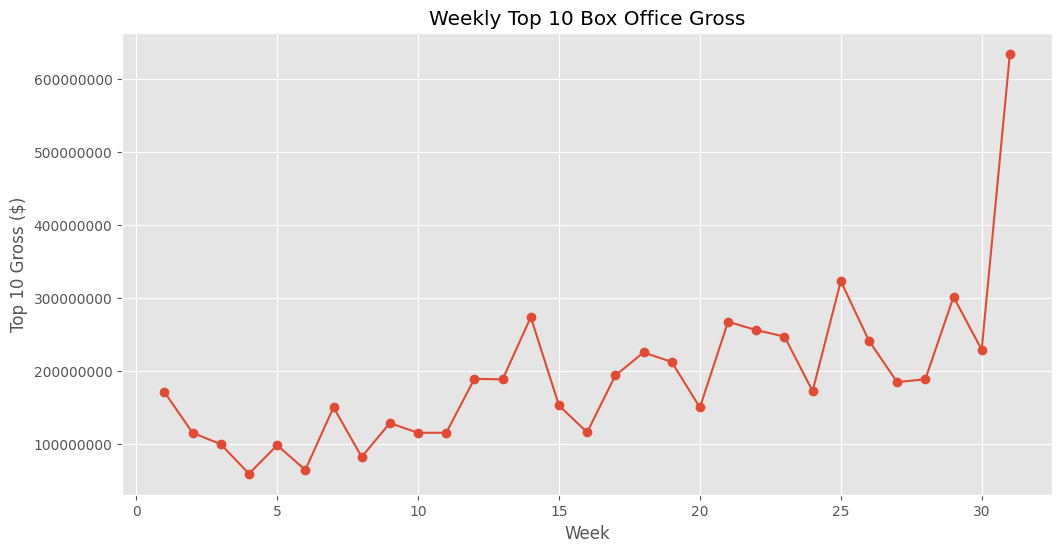

In [751]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df["Week"], df["Top 10 Gross"], marker="o")

plt.title("Weekly Top 10 Box Office Gross")
plt.xlabel("Week")
plt.ylabel("Top 10 Gross ($)")

plt.ticklabel_format(style="plain", axis="y")

plt.grid(True)
plt.show()

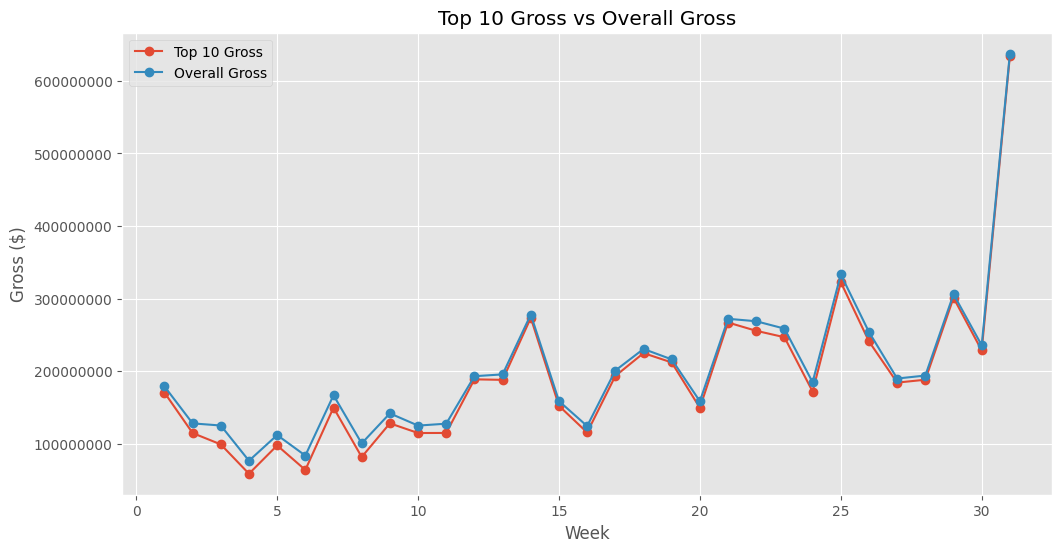

In [752]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df["Week"],
    df["Top 10 Gross"],
    marker="o",
    label="Top 10 Gross"
)

plt.plot(
    df["Week"],
    df["Overall Gross"],
    marker="o",
    label="Overall Gross"
)

plt.title("Top 10 Gross vs Overall Gross")
plt.xlabel("Week")
plt.ylabel("Gross ($)")

plt.ticklabel_format(style="plain", axis="y")

plt.legend()
plt.grid(True)

plt.show()

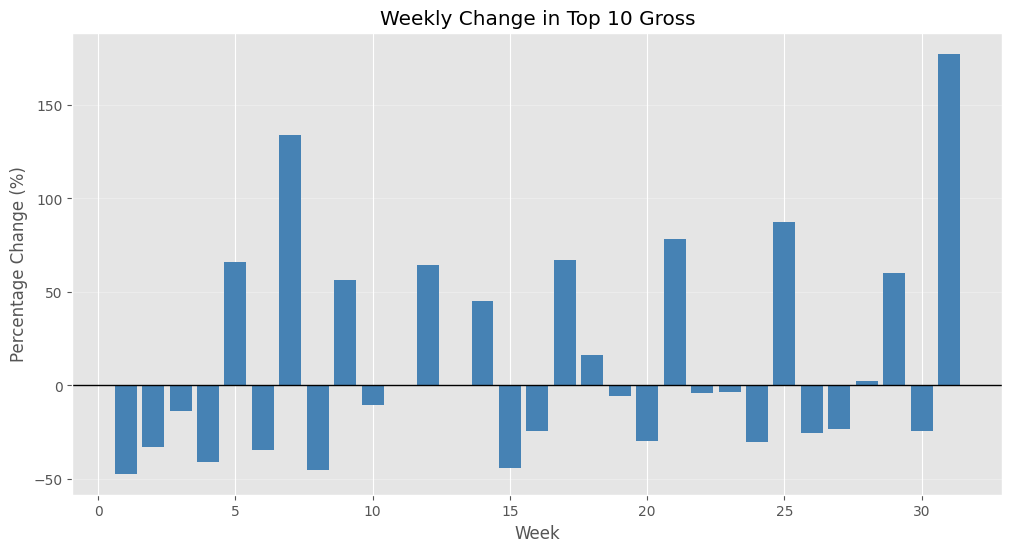

In [753]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    df["Week"],
    df["%± LW"],
    color="steelblue"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Weekly Change in Top 10 Gross")
plt.xlabel("Week")
plt.ylabel("Percentage Change (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [754]:
biggest_increase = df.loc[df["%± LW"].idxmax()]

print("Biggest weekly increase:")
print(f"Date: {biggest_increase['Dates']}")
print(f"Percentage increase: {biggest_increase['%± LW']}%")
print(f"Top 10 Gross: ${biggest_increase['Top 10 Gross']:,.2f}")
print(f"#1 Release: {biggest_increase['#1 Release']}")

Biggest weekly increase:
Date: Jul 31-Aug 6
Percentage increase: 177.4%
Top 10 Gross: $634,397,694.00
#1 Release: Spider-Man: Brand New Day


In [755]:
biggest_decrease = df.loc[df["%± LW"].idxmin()]

print("Biggest weekly decrease:")
print(f"Date: {biggest_decrease['Dates']}")
print(f"Percentage decrease: {biggest_decrease['%± LW']}%")
print(f"Top 10 Gross: ${biggest_decrease['Top 10 Gross']:,.2f}")
print(f"#1 Release: {biggest_decrease['#1 Release']}")

Biggest weekly decrease:
Date: Jan 2-8
Percentage decrease: -47.2%
Top 10 Gross: $170,708,999.00
#1 Release: Avatar: Fire and Ash


# Task 3: Data Visualization

In [756]:
!pip install seaborn




Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [757]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

<Axes: xlabel='Top 10 Gross'>

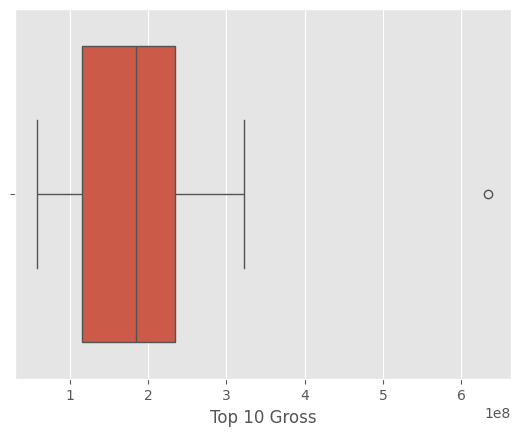

In [758]:
sns.boxplot(x=df["Top 10 Gross"])

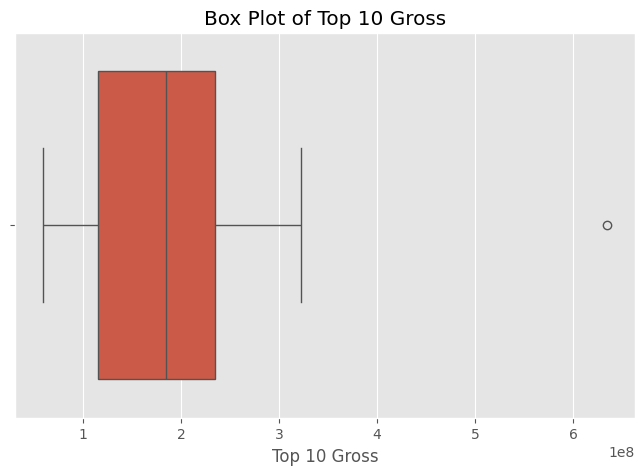

In [759]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Top 10 Gross"])
plt.title("Box Plot of Top 10 Gross")
plt.xlabel("Top 10 Gross")
plt.show()

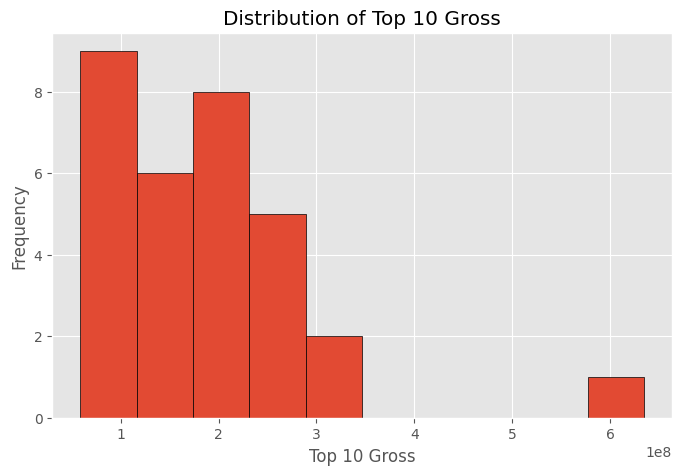

In [760]:
plt.figure(figsize=(8,5))
plt.hist(df["Top 10 Gross"], bins=10, edgecolor="black")
plt.title("Distribution of Top 10 Gross")
plt.xlabel("Top 10 Gross")
plt.ylabel("Frequency")
plt.show()

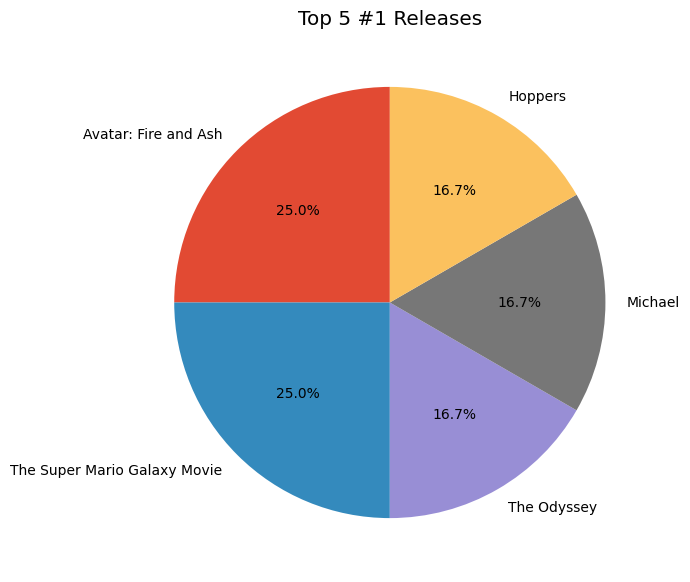

In [761]:
top5 = df["#1 Release"].value_counts().head(5)

plt.figure(figsize=(7,7))
plt.pie(top5.values, labels=top5.index, autopct="%1.1f%%", startangle=90)
plt.title("Top 5 #1 Releases")
plt.show()

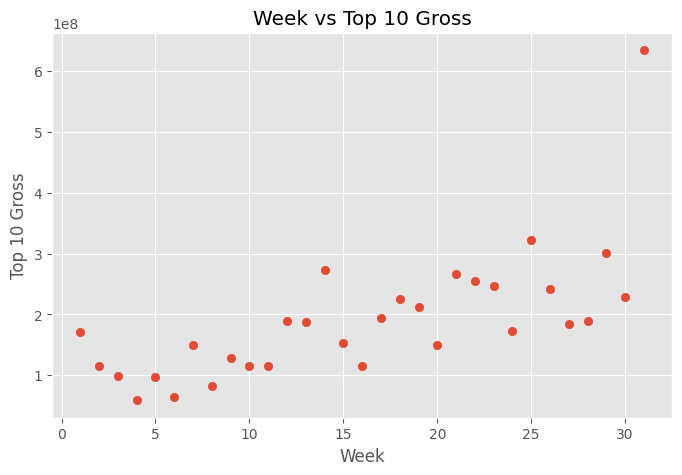

In [762]:
plt.figure(figsize=(8,5))
plt.scatter(df["Week"], df["Top 10 Gross"])
plt.title("Week vs Top 10 Gross")
plt.xlabel("Week")
plt.ylabel("Top 10 Gross")
plt.show()

## Observations

- The histogram shows the distribution of Top 10 Gross values.
- The pie chart displays the most frequent #1 movie releases.
- The box plot reveals an outlier with exceptionally high gross.
- The scatter plot helps visualize the relationship between Week and Top 10 Gross.
- The heatmap shows correlations among numerical columns.

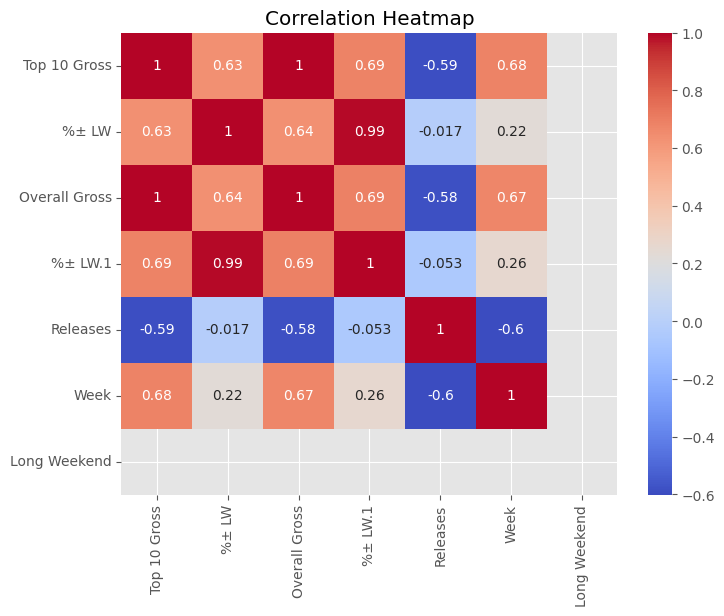

In [763]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ✅ Task 4: Sentiment Analysis

## Objective
Analyze movie review text using Natural Language Processing (NLP) to classify sentiments as Positive, Negative, or Neutral.

In [764]:
%pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [765]:
import pandas as pd
from textblob import TextBlob

In [766]:
reviews = {
    "Review": [
        "Amazing movie with great acting!",
        "The movie was average.",
        "Worst movie I have ever watched.",
        "Excellent storyline and visuals.",
        "Not bad but could be better.",
        "Fantastic experience!",
        "Very boring and slow.",
        "It was okay.",
        "Loved every moment.",
        "Terrible ending."
    ]
}

review_df = pd.DataFrame(reviews)
review_df

,Review
0,Amazing movie with great acting!
1,The movie was average.
2,Worst movie I have ever watched.
3,Excellent storyline and visuals.
4,Not bad but could be better.
5,Fantastic experience!
6,Very boring and slow.
7,It was okay.
8,Loved every moment.
9,Terrible ending.


In [767]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [768]:
review_df["Sentiment"] = review_df["Review"].apply(get_sentiment)
review_df

,Review,Sentiment
0,Amazing movie with great acting!,Positive
1,The movie was average.,Negative
2,Worst movie I have ever watched.,Negative
3,Excellent storyline and visuals.,Positive
4,Not bad but could be better.,Positive
5,Fantastic experience!,Positive
6,Very boring and slow.,Negative
7,It was okay.,Positive
8,Loved every moment.,Positive
9,Terrible ending.,Negative


In [769]:
review_df["Sentiment"].value_counts()

Sentiment
Positive    6
Negative    4
Name: count, dtype: int64

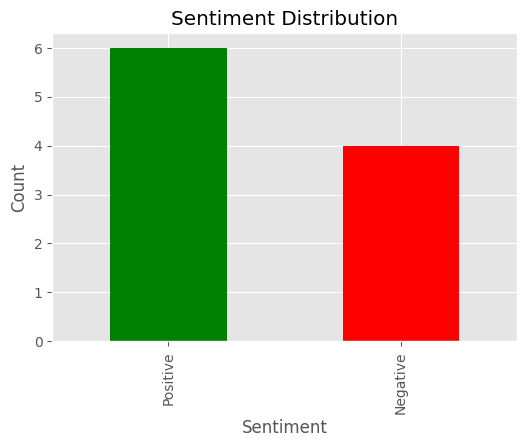

In [770]:
import matplotlib.pyplot as plt

review_df["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color=["green", "red", "gray"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [772]:
review_df.to_csv("movie_review_sentiment.csv", index=False)